
<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<h1 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    text-align:center;
    font-weight:bold;
    padding:18px 12px;
    border-radius:10px;
    margin-bottom:7px;">
    Day 1 — NLP & Text Preprocessing
</h1>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">
    From Messy Raw Text to Clean, Consistent, Task-Aware Input
</h3>

<div style="
    border-left:6px solid #FB7185;
    background-color:#FFF1F2;
    padding:12px 16px;
    margin:16px 0;
    border-radius:6px;
    color:#7F1D1D;">
    <b>Week 8 — NLP & Computer Vision • Sprint 3</b><br>
    This notebook covers the complete technical content of Day 1:
    raw text, tokenization, cleaning, normalization, stop-word removal,
    lemmatization, stemming comparison, task-dependent preprocessing,
    and a complete hands-on cleaning pipeline using the IMDb 50K Movie Reviews dataset.
</div>

<div style="
    display:flex;
    gap:10px;
    flex-wrap:wrap;
    justify-content:center;
    margin:14px 0;">
    <span style="background:#CCFBF1; color:#0F766E; padding:7px 12px; border-radius:18px; font-weight:bold;">NLP</span>
    <span style="background:#E0F2FE; color:#0284C7; padding:7px 12px; border-radius:18px; font-weight:bold;">Tokenization</span>
    <span style="background:#FFFBEB; color:#92400E; padding:7px 12px; border-radius:18px; font-weight:bold;">Cleaning</span>
    <span style="background:#FFF1F2; color:#9F1239; padding:7px 12px; border-radius:18px; font-weight:bold;">Stop Words</span>
    <span style="background:#DCFCE7; color:#15803D; padding:7px 12px; border-radius:18px; font-weight:bold;">Lemmatization</span>
</div>

<a id="toc"></a>
<h2 style="color:#92400E; background-color:#FBBF24; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">
Table of Contents
</h2>

<div style="border:1px solid #CBD5E1; padding:16px 25px; border-radius:8px; background-color:#FFFFFF; color:#111827;">
<ul style="font-weight:bold; line-height:1.95; color:#1F2937;">
<li><a href="#section0">0. Setup — Imports, Reproducibility & NLTK Resources</a></li>
<li><a href="#section1">1. Day 1 Roadmap & Requirement Coverage</a></li>
<li><a href="#section2">2. Dataset — IMDb 50K Movie Reviews</a></li>
<li><a href="#section3">3. NLP & Raw Text</a></li>
<li><a href="#section4">4. Why Text Needs Preprocessing</a></li>
<li><a href="#section5">5. Tokenization — Word & Sub-word</a></li>
<li><a href="#section6">6. Cleaning & Normalization</a></li>
<li><a href="#section7">7. Stop-word Removal</a></li>
<li><a href="#section8">8. Lemmatization</a></li>
<li><a href="#section9">9. Lemmatization vs. Stemming</a></li>
<li><a href="#section10">10. Task-Dependent Preprocessing</a></li>
<li><a href="#section11">11. Full Text-Cleaning Pipeline</a></li>
<li><a href="#section12">12. Apply the Pipeline to IMDb Reviews</a></li>
<li><a href="#section13">13. Before vs. After Analysis</a></li>
<li><a href="#section14">14. Signal-Preservation Checks</a></li>
<li><a href="#section16">16. What I Learned Today</a></li>
<li><a href="#section17">17. Day 2 Preview</a></li>
</ul>
</div>

<a id="section0"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    0. Setup — Imports, Reproducibility & NLTK Resources
</h2>

<div style="border-left:5px solid #0284C7; background-color:#E0F2FE; padding:11px 15px; margin:10px 0; border-radius:5px; color:#0C4A6E;">
<b>Dataset location:</b> This notebook is designed for your current folder structure:
<div style="
            background-color:#FFFFFF;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
Week 8/
└── Day 1/
    ├── Day1.ipynb
    ├── IMDB Dataset.csv.zip
    └── README.md
</div>
The code reads the ZIP file directly — you do <b>not</b> need to extract it manually.
</div>

In [1]:
# Core imports
from pathlib import Path
from collections import Counter
import random
import re
import html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Pandas version :", pd.__version__)
print("NumPy version  :", np.__version__)
print("NLTK version   :", nltk.__version__)

Pandas version : 2.3.3
NumPy version  : 2.3.5
NLTK version   : 3.9.2


<div style="border-left:5px solid #0F766E; background-color:#CCFBF1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#134E4A;">
<b>Reproducibility note:</b> A fixed seed keeps sampled examples consistent across runs, which makes notebook review and comparison easier.
</div>

In [2]:
# NLTK resources used today.
# Extra names support both older and newer NLTK versions.
resources = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for resource in resources:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

print("NLTK resources checked.")

NLTK resources checked.


<a id="section1"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    1. Day 1 Roadmap & Requirement Coverage
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>Today answers one main question:</p>
<div style="
    font-size:1.12em;
    font-weight:bold;
    text-align:center;
    background-color:#FFFBEB;
    border:1px solid #FBBF24;
    padding:16px;
    border-radius:8px;
    margin:14px 0; color:#111827;">
    How do we turn messy human text into clean, consistent text without destroying the meaning that matters to our task?
</div>

<div style="border:1px solid #CBD5E1; border-radius:7px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#0F766E; color:white;">
<th style="padding:9px; text-align:left;">Day 1 Requirement</th>
<th style="padding:9px; text-align:left;">Where It Is Covered</th>
</tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Understand why text needs preprocessing</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Sections 3–4</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Tokenize raw text</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Section 5</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Lowercase and remove punctuation/noise</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Section 6</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Remove stop words appropriately</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Section 7</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Apply lemmatization</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Section 8</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Compare lemmatization with stemming</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Section 9</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Preserve task-critical signal</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Sections 10 & 14</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Build a complete cleaning pipeline</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Sections 11–13</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Document preprocessing choices</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Throughout notebook + Section 15</td></tr>
</table>
</div>

<div style="border-left:5px solid #FB7185; background-color:#FFF1F2; padding:11px 15px; margin:14px 0; border-radius:5px; color:#881337;">
<b>Brief Sprint note:</b> Day 1 also opens Sprint 3 planning. Here the management part is intentionally kept short so the notebook stays focused on the NLP learning objectives.
</div>


</div>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Learning flow</h3>
<div style="
            background-color:#E0F2FE;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
Raw Text
   ↓
Tokenization
   ↓
Cleaning & Normalization
   ↓
Task-Aware Stop-word Removal
   ↓
Lemmatization
   ↓
Clean & Consistent Text
   ↓
Ready for Day 2: TF-IDF / Embeddings
</div>


</div>

<a id="section2"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    2. Dataset — IMDb 50K Movie Reviews
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>


<div class="day1-plain-markdown">
<p>The dataset used today is the <b>IMDb Dataset of 50K Movie Reviews</b>.</p>
<p>It is ideal for Day 1 because it contains real review text with:</p>
<ul>
<li>upper/lowercase variation,</li>
<li>punctuation,</li>
<li>HTML tags such as <code>&lt;br /&gt;</code>,</li>
<li>contractions and negation,</li>
<li>many different word forms,</li>
<li>positive and negative sentiment labels.</li>
</ul>
<div style="border-left:5px solid #FBBF24; background-color:#FFFBEB; padding:11px 15px; margin:12px 0; border-radius:5px; color:#78350F;">
<b>Why sentiment is useful for learning preprocessing:</b> It makes the danger of destructive cleaning very clear.
For example, deleting <code>not</code> from <code>not good</code> can reverse the meaning.
</div>


</div>

In [3]:
# Locate the ZIP file robustly.
expected_name = "IMDB Dataset.csv.zip"

candidates = [
    Path(expected_name),
    Path.cwd() / expected_name,
]

# Helpful fallback if VS Code starts the kernel from a parent workspace folder.
for base in [Path.cwd(), *list(Path.cwd().parents)[:2]]:
    try:
        candidates.extend(base.glob(f"**/{expected_name}"))
    except Exception:
        pass

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not find '{expected_name}'. "
        "Keep the ZIP beside Day1.ipynb as shown above."
    )



In [4]:
# pandas can read the ZIP directly because it contains one CSV file.
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns      :", df.columns.tolist())

display(df.head())

Dataset shape: (50000, 2)
Columns      : ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Dataset quality checks
print("Missing values:")
display(df.isna().sum().to_frame("missing"))

print("\nDuplicate reviews:", df.duplicated(subset=["review"]).sum())

print("\nSentiment distribution:")
display(df["sentiment"].value_counts().to_frame("count"))

Missing values:


,missing
review,0
sentiment,0



Duplicate reviews: 418

Sentiment distribution:


,count
sentiment,
positive,25000
negative,25000


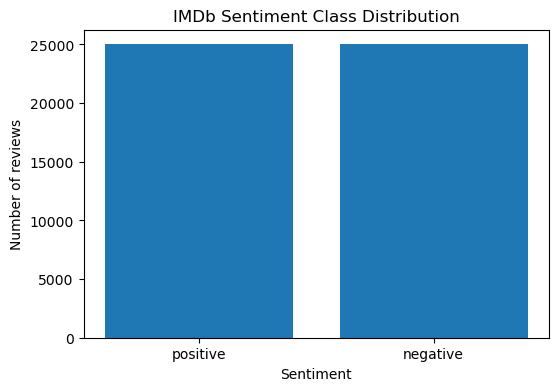

In [6]:
# Quick class-balance visualization
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.title("IMDb Sentiment Class Distribution")
plt.show()

<div style="border-left:5px solid #0F766E; background-color:#CCFBF1; padding:11px 15px; margin:12px 0; border-radius:5px; color:#134E4A;">
<b>Observation to write after running:</b> Check whether the classes are balanced and whether missing or duplicate reviews exist.
Understanding raw data comes before changing it.
</div>

<a id="section3"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    3. NLP & Raw Text
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.1 What is NLP?</h3>
<p><b>NLP (Natural Language Processing)</b> is the area of AI that works with human language.</p>
<p>Humans can read:</p>
<div style="
            background-color:#FFF7ED;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
This movie was absolutely amazing!
</div>

<p>and understand the meaning immediately. A machine-learning model ultimately works with numerical representations, so language must first be prepared.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.2 What is raw text?</h3>
<p><b>Raw text</b> means text exactly as it arrives before preprocessing.</p>
<p>It may contain:</p>
<ul>
<li>inconsistent capitalization,</li>
<li>punctuation,</li>
<li>numbers,</li>
<li>HTML,</li>
<li>common low-signal words,</li>
<li>contractions,</li>
<li>multiple forms of the same word.</li>
</ul>
<div style="background-color:#FFFBEB; border-left:5px solid #FBBF24; padding:11px 15px; border-radius:5px; color:#111827;">
<b>Important:</b> Day 1 does <u>not</u> convert text to TF-IDF or embeddings yet.
Day 1 prepares the text; Day 2 converts the cleaned text into numbers.
</div>


</div>

In [7]:
# Inspect one real raw IMDb review
raw_review = df.loc[0, "review"]

print("RAW REVIEW")
print("=" * 100)
print(raw_review[:1200])

print("\nType:", type(raw_review))
print("Characters:", len(raw_review))

RAW REVIEW
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

<a id="section4"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    4. Why Text Needs Preprocessing
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>Raw language is naturally inconsistent.</p>
<p>Consider:</p>
<div style="
            background-color:#E0F2FE;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
Good
good
good!
</div>

<p>A human recognizes the same basic word, but a text-processing system can treat these as different surface forms.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Two concepts we will use all day</h3>
<div style="display:grid; grid-template-columns:1fr 1fr; gap:12px;">
<div style="background:#FFF1F2; border:1px solid #FB7185; padding:12px; border-radius:7px; color:#111827;">
<b style="color:#9F1239;">Noise</b><br>
Information that does not help the current task.
</div>
<div style="background:#DCFCE7; border:1px solid #86EFAC; padding:12px; border-radius:7px; color:#111827;">
<b style="color:#15803D;">Signal</b><br>
Information that helps the model make the correct decision.
</div>
</div>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Goals of preprocessing</h3>
<ul>
<li>reduce unnecessary variation,</li>
<li>make the text more consistent,</li>
<li>reduce avoidable vocabulary growth,</li>
<li>remove selected noise,</li>
<li>preserve task-critical meaning.</li>
</ul>
<div style="border-left:5px solid #FB7185; background-color:#FFF1F2; padding:11px 15px; margin:12px 0; border-radius:5px; color:#881337;">
<b>Core rule:</b> Good preprocessing is not “maximum deletion.” It is useful cleaning that preserves meaning.
</div>


</div>

In [8]:
forms = ["Good", "good", "good!"]

simple_normalized = [
    re.sub(r"[^a-z]", "", item.lower())
    for item in forms
]

comparison = pd.DataFrame({
    "raw_form": forms,
    "simple_normalized_form": simple_normalized
})

display(comparison)

print("Unique raw forms       :", len(set(forms)))
print("Unique normalized forms:", len(set(simple_normalized)))

,raw_form,simple_normalized_form
0,Good,good
1,good,good
2,good!,good


Unique raw forms       : 3
Unique normalized forms: 1


<a id="section5"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    5. Tokenization — Word & Sub-word
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p><b>Tokenization</b> splits a text sequence into smaller units called <b>tokens</b>.</p>
<p>A token can be:</p>
<ul>
<li>a full word,</li>
<li>a sub-word,</li>
<li>or a character.</li>
</ul>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Word tokenization</h3>
<div style="
            background-color:#E0F2FE;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
"The movie was great!"
→ ["The", "movie", "was", "great", "!"]
</div>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Sub-word tokenization</h3>
<p>Modern transformer tokenizers can split an unfamiliar word into smaller known pieces.</p>
<p>Conceptually:</p>
<div style="
            background-color:#F5F3FF;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
playing → ["play", "ing"]
</div>

<p>The exact split depends on the tokenizer vocabulary.</p>
<div style="border-left:5px solid #0284C7; background-color:#E0F2FE; padding:11px 15px; margin:12px 0; border-radius:5px; color:#0C4A6E;">
<b>Important distinction:</b> Tokenization splits text. It does not automatically clean it or convert it to numbers.
</div>


</div>

In [9]:
sentence = "The movie was great!"

tokens = word_tokenize(sentence)

print("Original sentence:", sentence)
print("Tokens           :", tokens)
print("Number of tokens :", len(tokens))

Original sentence: The movie was great!
Tokens           : ['The', 'movie', 'was', 'great', '!']
Number of tokens : 5



<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Comparison — What each step does</h3>
<table>
<thead>
<tr>
  <th>Step</th>
  <th>Main job</th>
  <th>Example</th>
</tr>
</thead>
<tbody>
<tr>
  <td>Tokenization</td>
  <td>Split text into units</td>
  <td><code>&quot;great!&quot; → [&quot;great&quot;, &quot;!&quot;]</code></td>
</tr>
<tr>
  <td>Cleaning</td>
  <td>Remove selected noise</td>
  <td><code>[&quot;great&quot;, &quot;!&quot;] → [&quot;great&quot;]</code></td>
</tr>
<tr>
  <td>Numerical representation</td>
  <td>Convert text into numbers</td>
  <td>Happens on Day 2</td>
</tr>
</tbody>
</table>

</div>

<a id="section6"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    6. Cleaning & Normalization
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p><b>Cleaning</b> removes selected unwanted content.</p>
<p><b>Normalization</b> makes text more consistent.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.1 Lowercasing</h3>
<div style="
            background-color:#CCFBF1;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
Good, GOOD, good → good
</div>

<p>This reduces case-based variation.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.2 Punctuation removal</h3>
<div style="
            background-color:#CCFBF1;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
great! → great
</div>

<p>Punctuation can be removed when it is not useful for the task.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.3 Numbers</h3>
<p>Numbers are <b>not automatically noise</b>.</p>
<p>For sentiment analysis:</p>
<div style="
            background-color:#FFFBEB;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
"This movie is 10/10"
</div>

<p>The rating may contain useful sentiment signal. Therefore, deleting numbers should be a deliberate choice.</p>

</div>

In [10]:
cleaning_example = "WOW!!! This MOVIE was REALLY good!!! 10/10"

lower_text = cleaning_example.lower()
tokens = word_tokenize(lower_text)
alphabetic_only = [token for token in tokens if token.isalpha()]

print("Original:")
print(cleaning_example)

print("\n1) Lowercased:")
print(lower_text)

print("\n2) Tokenized:")
print(tokens)

print("\n3) Alphabetic tokens only:")
print(alphabetic_only)

Original:
WOW!!! This MOVIE was REALLY good!!! 10/10

1) Lowercased:
wow!!! this movie was really good!!! 10/10

2) Tokenized:
['wow', '!', '!', '!', 'this', 'movie', 'was', 'really', 'good', '!', '!', '!', '10/10']

3) Alphabetic tokens only:
['wow', 'this', 'movie', 'was', 'really', 'good']



<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Comparison — Cleaning vs. Normalization</h3>
<table>
<thead>
<tr>
  <th>Concept</th>
  <th>Purpose</th>
  <th>Example</th>
</tr>
</thead>
<tbody>
<tr>
  <td>Cleaning</td>
  <td>Remove selected noise</td>
  <td><code>great!!! → great</code></td>
</tr>
<tr>
  <td>Normalization</td>
  <td>Reduce variation</td>
  <td><code>GOOD → good</code></td>
</tr>
<tr>
  <td>Both together</td>
  <td>Create more consistent text</td>
  <td>messy text → standardized text</td>
</tr>
</tbody>
</table>
<div style="border-left:5px solid #FBBF24; background-color:#FFFBEB; padding:11px 15px; border-radius:5px; color:#78350F;">
<b>Decision question:</b> “Does this cleaning step remove noise, or does it remove useful signal?”
</div>


</div>

<a id="section7"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    7. Stop-word Removal
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p><b>Stop words</b> are very common words that may carry little useful signal for a specific task.</p>
<p>Examples:</p>
<div style="
            background-color:#E0F2FE;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
the, is, a
</div>

<p>Removing some stop words can reduce low-value text and vocabulary size.</p>
<p>However, stop-word removal must be <b>task-dependent</b>.</p>

</div>

In [11]:
english_stopwords = set(stopwords.words("english"))

print("Number of English NLTK stop words:", len(english_stopwords))
print("Sample:", sorted(list(english_stopwords))[:30])

Number of English NLTK stop words: 198
Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't"]


In [12]:
sentence = "this movie is not good"
tokens = word_tokenize(sentence.lower())

blind_result = [
    token for token in tokens
    if token not in english_stopwords
]

NEGATIONS_TO_KEEP = {"not", "no", "nor", "never"}
sentiment_stopwords = english_stopwords - NEGATIONS_TO_KEEP

task_aware_result = [
    token for token in tokens
    if token not in sentiment_stopwords
]

print("Original tokens            :", tokens)
print("Blind stop-word removal    :", blind_result)
print("Task-aware removal         :", task_aware_result)

Original tokens            : ['this', 'movie', 'is', 'not', 'good']
Blind stop-word removal    : ['movie', 'good']
Task-aware removal         : ['movie', 'not', 'good']


<div style="border-left:5px solid #B91C1C; background-color:#FEF2F2; padding:11px 15px; margin:12px 0; border-radius:5px; color:#7F1D1D;">
<b>Critical sentiment example:</b><br>
<code>good</code> and <code>not good</code> have very different meanings.
If <code>not</code> is removed, the preprocessing pipeline can reverse the meaning before the model sees the review.
</div>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Comparison — Blind vs. Task-Aware Stop-word Removal</h3>


| Approach | `"this movie is not good"` becomes | Risk |
|---|---|---|
| Blind removal | `movie good` | Negation is lost |
| Task-aware removal | `movie not good` | Important sentiment signal is preserved |

<a id="section8"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    8. Lemmatization
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p><b>Lemmatization</b> reduces different forms of a word to a meaningful dictionary base form.</p>
<p>Examples:</p>
<div style="
            background-color:#DCFCE7;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
running → run
ran     → run
cars    → car
</div>

<p>Why use it?</p>
<ul>
<li>reduce unnecessary vocabulary variation,</li>
<li>group related word forms,</li>
<li>preserve meaning better than crude word chopping.</li>
</ul>
<p>For more accurate lemmatization, this notebook uses <b>part-of-speech (POS)</b> information.</p>

</div>

In [13]:
lemmatizer = WordNetLemmatizer()

def to_wordnet_pos(treebank_tag):
    # Map Penn Treebank POS tags to WordNet POS tags.
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

words = ["running", "ran", "cars", "better"]
tagged_words = pos_tag(words)

rows = []
for word, tag in tagged_words:
    lemma = lemmatizer.lemmatize(word, to_wordnet_pos(tag))
    rows.append((word, tag, lemma))

display(pd.DataFrame(rows, columns=["word", "POS tag", "lemma"]))

,word,POS tag,lemma
0,running,VBG,run
1,ran,NN,ran
2,cars,NNS,car
3,better,RBR,well


<div style="border-left:5px solid #0F766E; background-color:#CCFBF1; padding:11px 15px; border-radius:5px; color:#134E4A;">
<b>Why POS matters:</b> The same surface word can act as a noun, verb, adjective, or adverb.
Giving the lemmatizer grammatical context helps it choose a more useful base form.
</div>

<a id="section9"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    9. Lemmatization vs. Stemming
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>Both techniques reduce word-form variation, but they are not the same.</p>
<div style="border:1px solid #CBD5E1; border-radius:7px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#0F766E; color:white;">
<th style="padding:9px; text-align:left;">Stemming</th>
<th style="padding:9px; text-align:left;">Lemmatization</th>
</tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Cuts endings mechanically</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Uses a dictionary-like base form</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Can create non-words</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Usually produces real words</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Fast and aggressive</td><td style="padding:9px; border-top:1px solid #E2E8F0;">More linguistically informed</td></tr>
<tr><td style="padding:9px; border-top:1px solid #E2E8F0;">Meaning preservation is weaker</td><td style="padding:9px; border-top:1px solid #E2E8F0;">Usually preserves meaning better</td></tr>
</table>
</div>


</div>

In [14]:
stemmer = PorterStemmer()

comparison_words = [
    "studies",
    "studying",
    "running",
    "connected",
    "better",
    "universities",
]

comparison_rows = []

for word in comparison_words:
    tag = pos_tag([word])[0][1]
    comparison_rows.append({
        "word": word,
        "stem": stemmer.stem(word),
        "lemma": lemmatizer.lemmatize(word, to_wordnet_pos(tag)),
    })

display(pd.DataFrame(comparison_rows))

,word,stem,lemma
0,studies,studi,study
1,studying,studi,study
2,running,run,run
3,connected,connect,connect
4,better,better,well
5,universities,univers,university


<div style="border-left:5px solid #FB7185; background-color:#FFF1F2; padding:11px 15px; border-radius:5px; color:#881337;">
<b>Today’s choice:</b> We use lemmatization in the final pipeline because the Day 1 goal is to reduce vocabulary variation while preserving task-relevant meaning.
</div>

<a id="section10"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    10. Task-Dependent Preprocessing
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>There is no single preprocessing pipeline that is correct for every NLP problem.</p>
<p>A feature can be <b>noise in one task</b> and <b>signal in another</b>.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Examples</h3>
<table>
<thead>
<tr>
  <th>Information</th>
  <th style="text-align:right">Could remove?</th>
  <th style="text-align:right">Could keep?</th>
  <th>Why</th>
</tr>
</thead>
<tbody>
<tr>
  <td><code>not</code></td>
  <td style="text-align:right">Sometimes</td>
  <td style="text-align:right"><strong>Yes for sentiment</strong></td>
  <td>Changes polarity</td>
</tr>
<tr>
  <td><code>10/10</code></td>
  <td style="text-align:right">Sometimes</td>
  <td style="text-align:right">Yes</td>
  <td>Can express rating</td>
</tr>
<tr>
  <td><code>!!!</code></td>
  <td style="text-align:right">Often</td>
  <td style="text-align:right">Sometimes</td>
  <td>May encode emotion/intensity</td>
</tr>
<tr>
  <td>Capitalization</td>
  <td style="text-align:right">Often normalize</td>
  <td style="text-align:right">Sometimes preserve</td>
  <td>ALL CAPS may encode emphasis</td>
</tr>
<tr>
  <td>HTML tags</td>
  <td style="text-align:right">Usually yes</td>
  <td style="text-align:right">Rarely useful here</td>
  <td>Formatting noise in IMDb reviews</td>
</tr>
</tbody>
</table>
<div style="background-color:#FFFBEB; border-left:5px solid #FBBF24; padding:11px 15px; border-radius:5px; color:#111827;">
<b>Professional preprocessing question:</b><br>
Before deleting anything, ask: “Does this element contain information my task needs?”
</div>


</div>

In [15]:
task_example = "WOW!!! I do NOT like this movie. 2/10"

# A deliberately aggressive cleaning example
aggressive_text = re.sub(r"[^a-zA-Z\s]", " ", task_example.lower())
aggressive_tokens = [
    t for t in word_tokenize(aggressive_text)
    if t.isalpha() and t not in english_stopwords
]

# A sentiment-aware version that keeps negation
aware_tokens = [
    t for t in word_tokenize(aggressive_text)
    if t.isalpha() and t not in sentiment_stopwords
]

print("Original text:")
print(task_example)

print("\nAggressive cleaning:")
print(aggressive_tokens)

print("\nSentiment-aware cleaning:")
print(aware_tokens)

print("\nKey idea: 'not like' should survive in a sentiment task.")

Original text:
WOW!!! I do NOT like this movie. 2/10

Aggressive cleaning:
['wow', 'like', 'movie']

Sentiment-aware cleaning:
['wow', 'not', 'like', 'movie']

Key idea: 'not like' should survive in a sentiment task.


<a id="section11"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    11. Full Text-Cleaning Pipeline
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>Now we combine the Day 1 concepts into one reusable function.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Pipeline design</h3>
<div style="
            background-color:#E0F2FE;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
Raw IMDb Review
      ↓
HTML cleanup
      ↓
Lowercase
      ↓
Normalize common negation contractions
      ↓
Tokenize
      ↓
Filter punctuation / optional numbers
      ↓
Task-aware stop-word removal
      ↓
POS-aware lemmatization
      ↓
Clean tokens
      ↓
Clean text
</div>

<div style="border-left:5px solid #FB7185; background-color:#FFF1F2; padding:11px 15px; border-radius:5px; color:#881337;">
<b>IMDb-specific choice:</b> We remove HTML formatting such as <code>&lt;br /&gt;</code> because it is page-formatting noise, not movie sentiment.
</div>


</div>

In [16]:
# Reusable resources for the final pipeline
BASE_STOPWORDS = set(stopwords.words("english"))
NEGATIONS_TO_KEEP = {"not", "no", "nor", "never"}

def normalize_negation_contractions(text):
    # Expand common English n't contractions so negation survives token filtering.
    # Examples: didn't -> did not, wasn't -> was not, isn't -> is not
    return re.sub(r"n['’]t\b", " not", text)

def preprocess_text(
    text,
    *,
    remove_stopwords=True,
    keep_negations=True,
    lemmatize=True,
    keep_numbers=False,
):
    # Day 1 IMDb preprocessing pipeline.
    # The function returns a list of clean tokens.

    # 1) Ensure string input
    text = str(text)

    # 2) Decode HTML entities and remove HTML tags
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)

    # 3) Lowercase
    text = text.lower()

    # 4) Preserve explicit negation from common n't contractions
    text = normalize_negation_contractions(text)

    # 5) Tokenize
    tokens = word_tokenize(text)

    # 6) Keep alphabetic tokens; optionally retain pure numbers
    if keep_numbers:
        tokens = [t for t in tokens if t.isalpha() or t.isdigit()]
    else:
        tokens = [t for t in tokens if t.isalpha()]

    # 7) Task-aware stop-word removal
    if remove_stopwords:
        active_stopwords = BASE_STOPWORDS.copy()
        if keep_negations:
            active_stopwords -= NEGATIONS_TO_KEEP

        tokens = [t for t in tokens if t not in active_stopwords]

    # 8) POS-aware lemmatization
    if lemmatize and tokens:
        tagged_tokens = pos_tag(tokens)
        tokens = [
            lemmatizer.lemmatize(token, to_wordnet_pos(tag))
            for token, tag in tagged_tokens
        ]

    return tokens

def preprocess_to_string(text, **kwargs):
    # Return the clean tokens joined back into one string.
    return " ".join(preprocess_text(text, **kwargs))

In [17]:
# Step-by-step demonstration on one short review
demo = "The MOVIE was not AMAZING!!! I wouldn't watch it again. 2/10 <br /><br />"

print("RAW:")
print(demo)

print("\nCLEAN TOKENS:")
print(preprocess_text(demo))

print("\nCLEAN TEXT:")
print(preprocess_to_string(demo))

RAW:
The MOVIE was not AMAZING!!! I wouldn't watch it again. 2/10 <br /><br />

CLEAN TOKENS:
['movie', 'not', 'amaze', 'would', 'not', 'watch']

CLEAN TEXT:
movie not amaze would not watch



<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Pipeline comparison</h3>
<table>
<thead>
<tr>
  <th>Stage</th>
  <th>Example output</th>
</tr>
</thead>
<tbody>
<tr>
  <td>Raw</td>
  <td><code>The MOVIE was not AMAZING!!! ...</code></td>
</tr>
<tr>
  <td>Lowercase</td>
  <td><code>the movie was not amazing!!! ...</code></td>
</tr>
<tr>
  <td>Tokenized</td>
  <td>separate tokens</td>
</tr>
<tr>
  <td>Stop-word filtered</td>
  <td>low-signal common words removed</td>
</tr>
<tr>
  <td>Lemmatized</td>
  <td>related forms normalized</td>
</tr>
<tr>
  <td>Final</td>
  <td>clean, task-aware text</td>
</tr>
</tbody>
</table>
<div style="border-left:5px solid #15803D; background-color:#DCFCE7; padding:11px 15px; border-radius:5px; color:#14532D;">
<b>Important:</b> The output is still text. Numerical representation with TF-IDF or embeddings belongs to Day 2.
</div>


</div>

<a id="section12"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    12. Apply the Pipeline to IMDb Reviews
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>The full IMDb dataset contains 50,000 long reviews. POS-aware lemmatization is intentionally more expensive than simple regex cleaning.</p>
<p>For a classroom notebook, we use a reproducible working sample by default.</p>
<ul>
<li>Set <code>PROCESS_FULL_DATASET = False</code> for fast learning and demonstrations.</li>
<li>Set <code>PROCESS_FULL_DATASET = True</code> when you want to preprocess all 50,000 reviews.</li>
</ul>
<div style="border-left:5px solid #0284C7; background-color:#E0F2FE; padding:11px 15px; border-radius:5px; color:#0C4A6E;">
<b>Why sample for learning?</b> The concepts and pipeline remain identical, but the notebook runs much faster during class and review.
</div>


</div>

In [18]:
PROCESS_FULL_DATASET = False
SAMPLE_SIZE = 5000

if PROCESS_FULL_DATASET:
    df_work = df.copy()
else:
    sample_n = min(SAMPLE_SIZE, len(df))
    df_work = df.sample(n=sample_n, random_state=SEED).copy()

df_work = df_work.dropna(subset=["review", "sentiment"]).reset_index(drop=True)

print("Rows used for preprocessing:", len(df_work))
print("\nClass distribution:")
display(df_work["sentiment"].value_counts().to_frame("count"))

Rows used for preprocessing: 5000

Class distribution:


,count
sentiment,
positive,2519
negative,2481


In [19]:
# Apply the full Day 1 pipeline
df_work["clean_review"] = df_work["review"].apply(preprocess_to_string)

display(
    df_work[["review", "clean_review", "sentiment"]]
    .head(5)
)

,review,clean_review,sentiment
0,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...,positive
1,Not many television shows appeal to quite as m...,not many television show appeal quite many dif...,positive
2,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...,negative
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve one gwyne...,positive
4,Expectations were somewhat high for me when I ...,expectation somewhat high go see movie think s...,negative


<div style="border-left:5px solid #FB7185; background-color:#FFF1F2; padding:11px 15px; border-radius:5px; color:#881337;">
<b>What to inspect:</b> Do not only ask “Did the code run?” Read several before/after examples.
Professional preprocessing includes qualitative checking.
</div>

<a id="section13"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    13. Before vs. After Analysis
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>A good notebook should measure what preprocessing changed.</p>
<p>We will compare:</p>
<ol>
<li>review length,</li>
<li>vocabulary size,</li>
<li>common words,</li>
<li>actual before/after review examples.</li>
</ol>

</div>

In [20]:
# Review length before and after preprocessing
df_work["raw_word_count"] = (
    df_work["review"]
    .astype(str)
    .str.split()
    .str.len()
)

df_work["clean_word_count"] = (
    df_work["clean_review"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    df_work[["raw_word_count", "clean_word_count"]]
    .describe()
    .round(2)
)

,raw_word_count,clean_word_count
count,5000.00,5000.00
mean,232.98,118.54
std,170.47,88.05
min,18.00,8.00
25%,126.00,63.00
50%,174.00,88.00
75%,286.00,145.00
max,1024.00,577.00


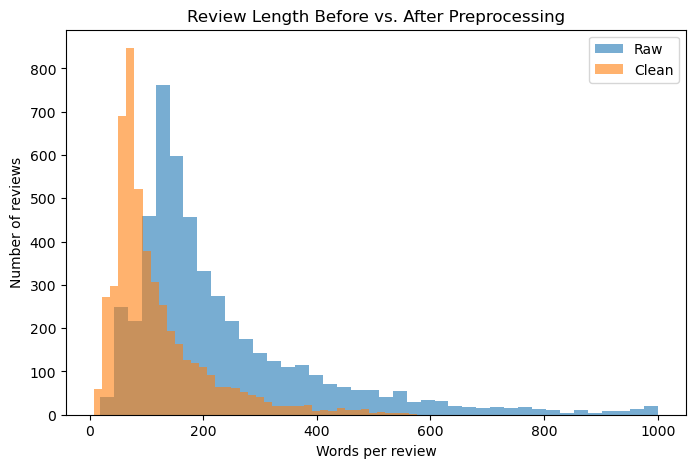

In [21]:
# One clear chart
plt.figure(figsize=(8, 5))

plt.hist(
    df_work["raw_word_count"].clip(upper=1000),
    bins=40,
    alpha=0.6,
    label="Raw"
)

plt.hist(
    df_work["clean_word_count"].clip(upper=1000),
    bins=40,
    alpha=0.6,
    label="Clean"
)

plt.xlabel("Words per review")
plt.ylabel("Number of reviews")
plt.title("Review Length Before vs. After Preprocessing")
plt.legend()
plt.show()

In [22]:
# Vocabulary comparison on the working sample
raw_counter = Counter()

for review in df_work["review"].astype(str):
    # Lowercase tokenization only, for a simple raw-vocabulary estimate.
    raw_counter.update(word_tokenize(review.lower()))

clean_counter = Counter()

for review in df_work["clean_review"]:
    clean_counter.update(review.split())

vocab_comparison = pd.DataFrame({
    "stage": ["Raw tokenized text", "Clean text"],
    "unique_tokens": [len(raw_counter), len(clean_counter)]
})

display(vocab_comparison)

reduction = 100 * (1 - len(clean_counter) / max(len(raw_counter), 1))
print(f"Approximate vocabulary reduction: {reduction:.2f}%")

,stage,unique_tokens
0,Raw tokenized text,49496
1,Clean text,31728


Approximate vocabulary reduction: 35.90%


In [23]:
# Most common clean words
top_clean_words = pd.DataFrame(
    clean_counter.most_common(20),
    columns=["word", "count"]
)

display(top_clean_words)

,word,count
0,not,12957
1,movie,10156
2,film,9775
3,one,5408
4,make,4364
5,like,4255
6,see,4091
7,get,3662
8,good,3430
9,time,3100


In [24]:
# Side-by-side text inspection
examples = df_work.sample(n=min(5, len(df_work)), random_state=SEED)[
    ["review", "clean_review", "sentiment"]
].copy()

for i, row in examples.reset_index(drop=True).iterrows():
    print("=" * 110)
    print(f"EXAMPLE {i + 1} | SENTIMENT: {row['sentiment'].upper()}")
    print("-" * 110)
    print("RAW:")
    print(row["review"][:700])
    print("\nCLEAN:")
    print(row["clean_review"][:700])
    print()

EXAMPLE 1 | SENTIMENT: POSITIVE
--------------------------------------------------------------------------------------------------------------
RAW:
When it comes to the erotic genre, I'm lucky to get through the first 20 minutes of the plot without getting up or looking for something else to watch. This movie is different. Julie Davis (I love You Don't Touch Me) directed two very strong lead actors Kira Reed and Doug Jeffery in this enthralling thriller. Kira is convincing as "Kim" a sweet innocent romance novelist that gets caught in the web of seduction of Doug Jeffery's "The Man" a handsome stranger. Kira loses control of her inhibitions in the role, and as actress, giving what could have been simply another T and A depth and believability. I believe it to be her best performance yet. And Julie Davis' direction is a great gift to ero

CLEAN:
come erotic genre lucky get first minute plot without get look something else watch movie different julie davis love not touch direct two stron

<div style="border-left:5px solid #FBBF24; background-color:#FFFBEB; padding:11px 15px; border-radius:5px; color:#78350F;">
<b>Interpret carefully:</b> A smaller vocabulary is not automatically “better.”
The real goal is to remove unnecessary variation while keeping the words and structures that matter for sentiment.
</div>

<a id="section14"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    14. Signal-Preservation Checks
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>The Day 1 requirements emphasize verifying that cleaning preserves task-critical words.</p>
<p>For sentiment analysis, one of the most important checks is <strong>negation</strong>.</p>

</div>

In [25]:
# Find reviews with explicit negation and inspect whether it survives.
negation_mask = df_work["review"].astype(str).str.contains(
    r"\bnot\b|n['’]t\b",
    case=False,
    regex=True,
    na=False,
)

negation_examples = df_work.loc[
    negation_mask,
    ["review", "clean_review", "sentiment"]
].head(8)

display(negation_examples)

,review,clean_review,sentiment
0,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...,positive
1,Not many television shows appeal to quite as m...,not many television show appeal quite many dif...,positive
2,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...,negative
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve one gwyne...,positive
4,Expectations were somewhat high for me when I ...,expectation somewhat high go see movie think s...,negative
5,I've watched this movie on a fairly regular ba...,watch movie fairly regular basis life never ge...,positive
6,For once a story of hope highlighted over the ...,story hope highlight tragic reality youth face...,positive
7,"Okay, I didn't get the Purgatory thing the fir...",okay not get purgatory thing first time watch ...,positive


In [26]:
# Quantitative check: how often does "not" survive after cleaning?
raw_not_count = df_work["review"].astype(str).str.contains(
    r"\bnot\b|n['’]t\b",
    case=False,
    regex=True,
    na=False,
).sum()

clean_not_count = df_work["clean_review"].astype(str).str.contains(
    r"\bnot\b",
    case=False,
    regex=True,
    na=False,
).sum()

print("Reviews with raw explicit negation :", raw_not_count)
print("Reviews with 'not' after cleaning  :", clean_not_count)
print()
print("The values do not need to be identical because contractions and context vary.")
print("The qualitative examples above are the important meaning-preservation check.")

Reviews with raw explicit negation : 4110
Reviews with 'not' after cleaning  : 4119

The values do not need to be identical because contractions and context vary.
The qualitative examples above are the important meaning-preservation check.



<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">Preprocessing decisions documented</h3>
<table>
<thead>
<tr>
  <th>Choice</th>
  <th>Decision in this notebook</th>
  <th>Reason</th>
</tr>
</thead>
<tbody>
<tr>
  <td>Lowercase</td>
  <td>Yes</td>
  <td>Reduce case variation</td>
</tr>
<tr>
  <td>HTML tags</td>
  <td>Remove</td>
  <td>Formatting noise in IMDb</td>
</tr>
<tr>
  <td>Punctuation</td>
  <td>Remove for this classical baseline</td>
  <td>Simplify text</td>
</tr>
<tr>
  <td>Numbers</td>
  <td>Remove by default</td>
  <td>Keep pipeline simple; can be toggled</td>
</tr>
<tr>
  <td>Stop words</td>
  <td>Remove selectively</td>
  <td>Reduce low-signal words</td>
</tr>
<tr>
  <td>Negation</td>
  <td><strong>Preserve</strong></td>
  <td>Critical for sentiment</td>
</tr>
<tr>
  <td>Lemmatization</td>
  <td>Yes</td>
  <td>Reduce word-form variation</td>
</tr>
<tr>
  <td>Stemming</td>
  <td>No in final pipeline</td>
  <td>More aggressive; may produce non-words</td>
</tr>
</tbody>
</table>
<div style="border-left:5px solid #15803D; background-color:#DCFCE7; padding:11px 15px; border-radius:5px; color:#14532D;">
<b>This table is important:</b> It shows that preprocessing choices are not random. Each one is justified by the task.
</div>


</div>

<a id="section16"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    15. What I Learned Today
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<ul>
<li><strong>NLP &amp; Raw Text:</strong> Learned how human language enters an NLP workflow before numerical representation.</li>
<li><strong>Text Preprocessing:</strong> Learned why raw text should be cleaned, standardized, and made more consistent.</li>
<li><strong>Tokenization:</strong> Learned how text is split into smaller processable tokens.</li>
<li><strong>Word &amp; Sub-word Tokenization:</strong> Learned the conceptual difference between complete-word and sub-word units.</li>
<li><strong>Cleaning &amp; Normalization:</strong> Learned how unnecessary variation and selected noise can be reduced.</li>
<li><strong>Lowercasing:</strong> Learned how case normalization reduces duplicate surface forms.</li>
<li><strong>Punctuation &amp; Numbers:</strong> Learned that they should be removed only when they do not contain useful task information.</li>
<li><strong>Stop-word Removal:</strong> Learned how common low-signal words may be removed.</li>
<li><strong>Negation Preservation:</strong> Learned why words such as <code>not</code> are critical in sentiment analysis.</li>
<li><strong>Lemmatization:</strong> Learned how different word forms can be reduced to meaningful base forms.</li>
<li><strong>Lemmatization vs. Stemming:</strong> Learned that stemming cuts endings mechanically while lemmatization is more linguistically informed.</li>
<li><strong>Noise vs. Signal:</strong> Learned how to distinguish removable noise from information the model needs.</li>
<li><strong>Task-Dependent Preprocessing:</strong> Learned that preprocessing choices must be justified by the actual NLP task.</li>
<li><strong>Full Pipeline:</strong> Learned how all Day 1 steps combine into one reusable preprocessing workflow.</li>
</ul>

</div>

<a id="section17"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    16. Day 2 Preview — From Clean Text to Numbers
</h2>


<style>
.day1-plain-markdown {
    background-color: #F8F8F8;
    color: #111111;
    border: 1px solid #E9E9E9;
    border-radius: 9px;
    padding: 16px 18px;
    margin: 10px 0 18px 0;
    line-height: 1.7;
}
.day1-plain-markdown p,
.day1-plain-markdown li,
.day1-plain-markdown td {
    color: #111111 !important;
}
.day1-plain-markdown strong,
.day1-plain-markdown b {
    color: #111111;
}
.day1-plain-markdown code {
    color: #111111;
}
</style>

<div class="day1-plain-markdown">
<p>At the end of Day 1, we have:</p>
<div style="
            background-color:#DCFCE7;
            color:#111827;
            padding:12px 14px;
            border-radius:8px;
            border:1px solid #CBD5E1;
            font-family:Consolas, 'Courier New', monospace;
            font-size:0.98em;
            font-weight:600;
            line-height:1.6;
            white-space:pre-wrap;
            margin:10px 0;">
Raw Text
   ↓
Clean, Consistent, Task-Aware Text
</div>

<p>But the model still needs numbers.</p>
<p>The next question is:</p>
<div style="
    font-size:1.12em;
    font-weight:bold;
    text-align:center;
    background-color:#FFFBEB;
    border:1px solid #FBBF24;
    padding:16px;
    border-radius:8px;
    margin:14px 0; color:#111827;">
    How do we represent text numerically while preserving useful information?
</div>

<p>Day 2 will answer that with:</p>
<ul>
<li><b>Bag of Words</b></li>
<li><b>TF-IDF</b></li>
<li><b>Word Embeddings</b></li>
<li><b>Word2Vec / GloVe</b></li>
<li>a comparison of frequency-based vs. semantic representations</li>
</ul>

</div>